# Thesis Analysis

Notebook ridotto a:
- configurazione dataset e stile
- validazioni sui CSV finali
- una cella per ogni grafico, con soli parametri e chiamata funzione


In [3]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "thesis_experiment").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks.analysis_tools import (
    APTOS_FONT_DIR,
    DEFAULT_RUN_SPECS,
    PLOT_CONDITION_ORDER,
    build_analysis_context,
    build_chunk_dashboard_tables,
    build_steps_summary_table,
    configure_matplotlib_font,
    plot_chunk_dashboard_v3,
    plot_episode_cost_dashboard_v3,
    plot_error_dashboard_v3,
    plot_steps_dashboard_v8,
    plot_task_condition_success_heatmap_light_continuous,
    plot_task_difficulty_v3,
    summarize_analysis_context,
)


In [4]:
SAVE_FIGURES = True
FIG_DIR = REPO_ROOT / "thesis_experiment" / "generated_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUN_SPECS = DEFAULT_RUN_SPECS
TASK_COL = "task_id"
COND_COL = "plot_condition"

FONT_DIR = APTOS_FONT_DIR
FONT_FAMILY = configure_matplotlib_font(FONT_DIR)
print(f"Matplotlib font family: {FONT_FAMILY}")

TEXT_STYLE = {
    "suptitle_fontsize": 30,
    "panel_title_fontsize": 24,
    "axis_label_fontsize": 22,
    "xtick_fontsize": 20,
    "ytick_fontsize": 20,
    "legend_fontsize": 18,
    "legend_title_fontsize": 18,
}

ANNOTATION_STYLE = {
    "annotation_fontsize": 18,
    "binary_label_fontsize": 18,
    "rate_label_fontsize": 18,
    "action_share_label_fontsize": 17,
    "cell_fontsize": 16,
}

COMMON_PLOT_STYLE = {
    "xlabels_two_lines": True,
    "xtick_rotation": 0,
    "xtick_pad": 14,
    "grid_alpha": 0.25,
    "save_dpi": 350,
}

FIGURE_STYLE = {
    "heatmap_figsize": (16.0, 9.2),
    "single_plot_figsize": (16.0, 9.2),
    "dashboard_1x2_figsize": (18.0, 9.6),
    "dashboard_2x2_figsize": (19.0, 14.4),
}


Matplotlib font family: None


In [5]:
FIGURE_STYLE["dashboard_2x2_figsize"]

(19.0, 14.4)

In [6]:
context = build_analysis_context(run_specs=RUN_SPECS)
df_all = context["df_all"]
run_inventory = context["run_inventory"]
chunks_piv = context["chunks_piv"]
steps_piv = context["steps_piv"]

display(run_inventory)
print("Total rows:", len(df_all))
print("Conditions:", ", ".join(PLOT_CONDITION_ORDER))


,run_id,run_label,csv_path,rows,conditions
0,baseline_run1,Baseline and warm LTM,..\thesis_experiment\experiments_final_v1_2026...,40,"Baseline | Vision ON, Baseline | Vision OFF, W..."
1,baseline_run2,Baseline and warm LTM,..\thesis_experiment\experiments_final_v1_2026...,40,"Baseline | Vision ON, Baseline | Vision OFF, W..."
2,baseline_run3,Baseline and warm LTM,..\thesis_experiment\experiments_final_v1_2026...,40,"Baseline | Vision ON, Baseline | Vision OFF, W..."
3,no_stm_run1,No STM,..\thesis_experiment\experiments_final_v2_stm_...,20,"No STM | Vision ON, No STM | Vision OFF"
4,no_stm_run2,No STM,..\thesis_experiment\experiments_final_v2_stm_...,20,"No STM | Vision ON, No STM | Vision OFF"
5,no_stm_run3,No STM,..\thesis_experiment\experiments_final_v2_stm_...,20,"No STM | Vision ON, No STM | Vision OFF"


Total rows: 180
Conditions: Baseline | Vision ON, Baseline | Vision OFF, No STM | Vision ON, No STM | Vision OFF, Warm LTM | Vision ON, Warm LTM | Vision OFF


In [7]:
summary = summarize_analysis_context(context)

display(pd.DataFrame([summary["completeness"]]))
display(summary["chunk_quality_comparison"])
display(chunks_piv)
display(steps_piv)


,rows_total,conditions,tasks_per_condition,runs_per_condition,duplicate_run_task_condition,ordered_conditions
0,180,"{'Baseline | Vision ON': 30, 'Baseline | Visio...","{'Baseline | Vision ON': 10, 'Baseline | Visio...","{'Baseline | Vision ON': 3, 'Baseline | Vision...",0,"[Baseline | Vision ON, Baseline | Vision OFF, ..."


,condition,weighted_chunk_rate_mean,episode_mean_chunk_rate_mean,mean_chunks_success_per_run,mean_chunks_fail_per_run,difference_weighted_minus_episode_mean
0,Baseline | Vision ON,0.536523,0.635807,3.433333,2.966667,-0.099284
1,Baseline | Vision OFF,0.535138,0.644537,3.666667,3.266667,-0.109399
2,No STM | Vision ON,0.591856,0.660714,3.633333,2.533333,-0.068858
3,No STM | Vision OFF,0.500717,0.620476,3.533333,3.533333,-0.119760
4,Warm LTM | Vision ON,0.477111,0.595754,3.300000,3.700000,-0.118643
5,Warm LTM | Vision OFF,0.549708,0.687183,3.466667,2.900000,-0.137475


plot_condition,Baseline | Vision ON,Baseline | Vision OFF,No STM | Vision ON,No STM | Vision OFF,Warm LTM | Vision ON,Warm LTM | Vision OFF
task_id,,,,,,
28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,3.00,3.00,3.00,3.00,3.00,3.00
3ce045a0-877b-42aa-8d2c-b4a863336ab8,10.00,5.33,6.00,8.33,9.00,7.67
5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,2.00,2.00,4.00,2.00,2.67,2.00
94d95f96-9699-4208-98ba-3c3119edf9c2,10.00,8.33,10.00,10.00,10.00,7.67
a4d98375-215b-4a4d-aee9-3d4370fccc41,6.67,9.00,7.00,7.67,10.00,9.00
b6781586-6346-41cd-935a-a6b1487918fc,9.67,10.00,10.00,7.67,10.00,10.00
bedcedc4-4d72-425e-ad62-21960b11fe0d,8.67,9.67,6.00,9.00,8.00,5.67
e0df059f-28a6-4169-924f-b9623e7184cc,7.33,9.67,8.67,10.00,8.33,10.00
ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,2.33,7.33,2.00,8.00,4.67,4.67


plot_condition,Baseline | Vision ON,Baseline | Vision OFF,No STM | Vision ON,No STM | Vision OFF,Warm LTM | Vision ON,Warm LTM | Vision OFF
task_id,,,,,,
28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,3.67,3.67,3.33,3.00,3.33,3.33
3ce045a0-877b-42aa-8d2c-b4a863336ab8,16.33,9.00,8.67,12.33,15.67,11.33
5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,3.00,3.00,4.00,3.00,3.33,3.00
94d95f96-9699-4208-98ba-3c3119edf9c2,14.00,12.00,13.33,13.00,12.67,10.67
a4d98375-215b-4a4d-aee9-3d4370fccc41,9.00,12.00,10.00,9.67,13.00,11.00
b6781586-6346-41cd-935a-a6b1487918fc,12.00,14.33,15.00,10.00,13.00,14.00
bedcedc4-4d72-425e-ad62-21960b11fe0d,12.33,12.33,10.67,10.67,12.33,8.33
e0df059f-28a6-4169-924f-b9623e7184cc,19.00,22.00,22.67,28.00,21.33,23.33
ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,3.33,11.33,3.00,12.00,8.00,6.67


## Task-condition heatmap


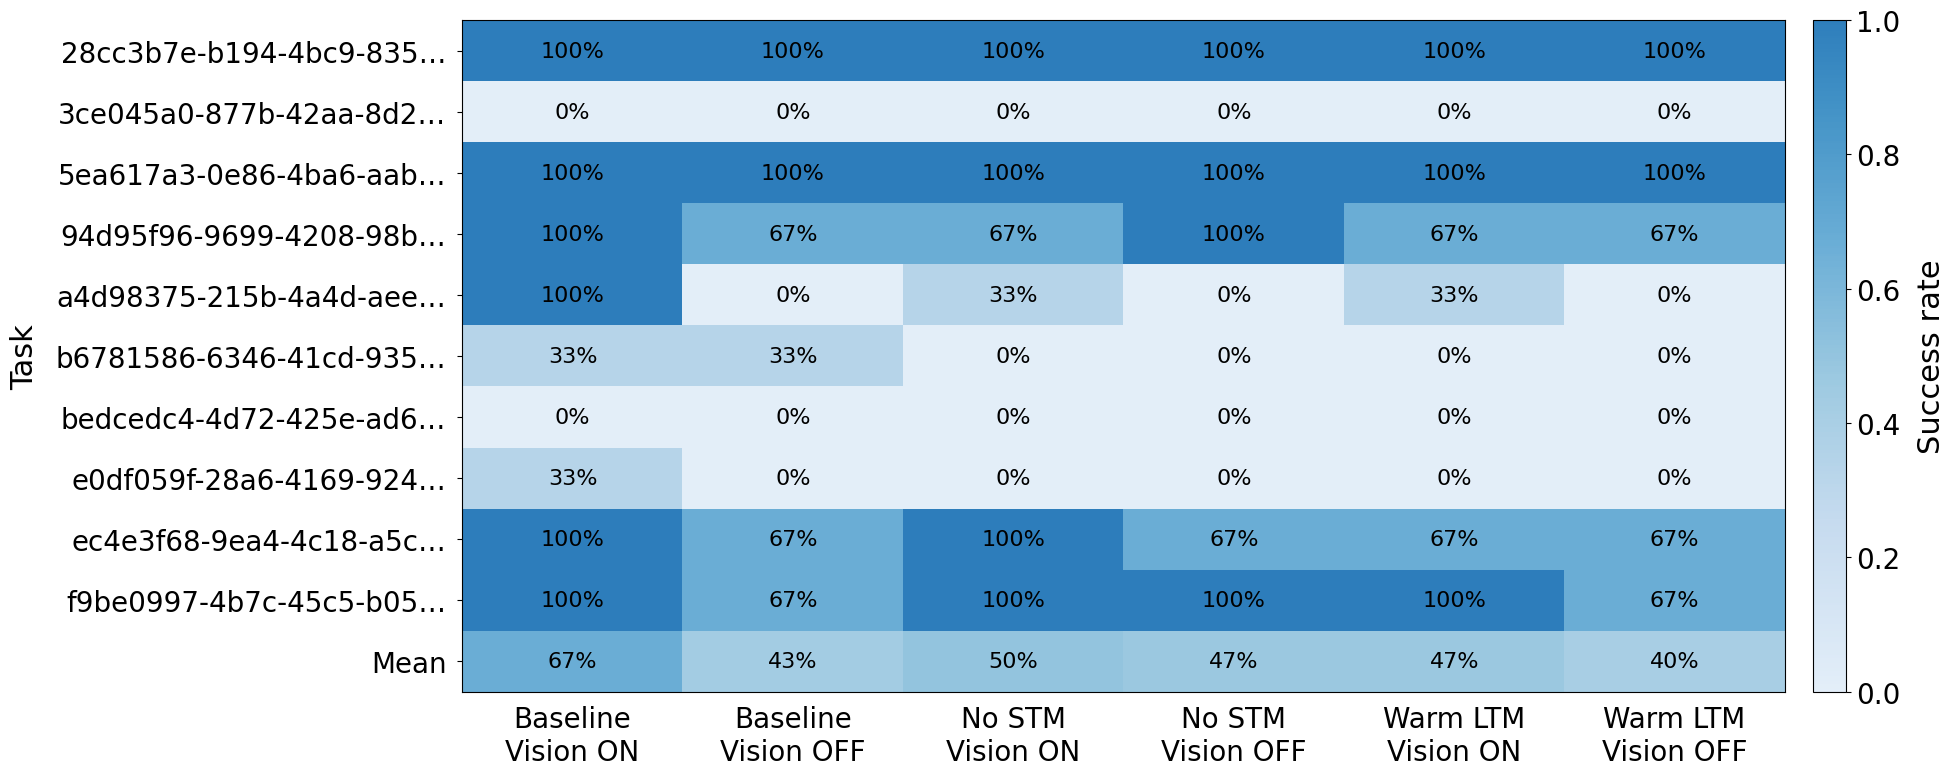

In [8]:
HEATMAP_PARAMS = {
    "cond_col": COND_COL,
    "outpath_png": str(FIG_DIR / "heatmap_success_task_condition_light_continuous.png") if SAVE_FIGURES else None,
    "annotate": True,
    "figsize": FIGURE_STYLE["heatmap_figsize"],
    "task_id_chars": 22,
    "cell_fontsize": ANNOTATION_STYLE["cell_fontsize"],
    "ytick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "xtick_fontsize": TEXT_STYLE["xtick_fontsize"],
    "axis_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "xlabels_two_lines": COMMON_PLOT_STYLE["xlabels_two_lines"],
    "title": "",
    "title_fontsize": TEXT_STYLE["panel_title_fontsize"],
    "annotation_as_percent": True,
    "colorbar_label": "Success rate",
    "colorbar_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "colorbar_tick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "left_margin": 0.08,
    "right_margin": 0.95,
    "bottom_margin": 0.20,
    "top_margin": 0.93,
    "include_mean_row": True,
    "mean_row_label": "Mean",
}

fig_heatmap, ax_heatmap, heatmap_pivot = plot_task_condition_success_heatmap_light_continuous(
    df_all,
    **HEATMAP_PARAMS,
)
plt.show()


## Task difficulty


,task_id,success_rate,duration_mean,llm_mean,chunk_rate_mean,step_rate_mean,task_label
0,3ce045a0-877b-42aa-8d2c-b4a863336ab8,0.000000,348.873556,21.166667,0.534127,0.551796,3ce045a0-877b-42aa-8d2c-b4a863336ab8
1,bedcedc4-4d72-425e-ad62-21960b11fe0d,0.000000,322.601778,21.611111,0.557077,0.572394,bedcedc4-4d72-425e-ad62-21960b11fe0d
2,e0df059f-28a6-4169-924f-b9623e7184cc,0.055556,579.547556,24.166667,0.217284,0.576730,e0df059f-28a6-4169-924f-b9623e7184cc
3,b6781586-6346-41cd-935a-a6b1487918fc,0.111111,397.299333,25.833333,0.487654,0.549733,b6781586-6346-41cd-935a-a6b1487918fc
4,a4d98375-215b-4a4d-aee9-3d4370fccc41,0.277778,308.805389,22.722222,0.692130,0.678805,a4d98375-215b-4a4d-aee9-3d4370fccc41
5,94d95f96-9699-4208-98ba-3c3119edf9c2,0.777778,384.890167,24.833333,0.540278,0.652325,94d95f96-9699-4208-98ba-3c3119edf9c2
6,ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,0.777778,211.849556,13.611111,0.512434,0.630928,ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3
7,f9be0997-4b7c-45c5-b05c-4612b44a6118,0.888889,167.115611,13.111111,0.922024,0.894655,f9be0997-4b7c-45c5-b05c-4612b44a6118
8,28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,1.000000,118.710611,9.000000,1.000000,1.000000,28cc3b7e-b194-4bc9-8353-d04c0f4d56d2
9,5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,1.000000,95.715611,7.333333,0.944444,0.944444,5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57


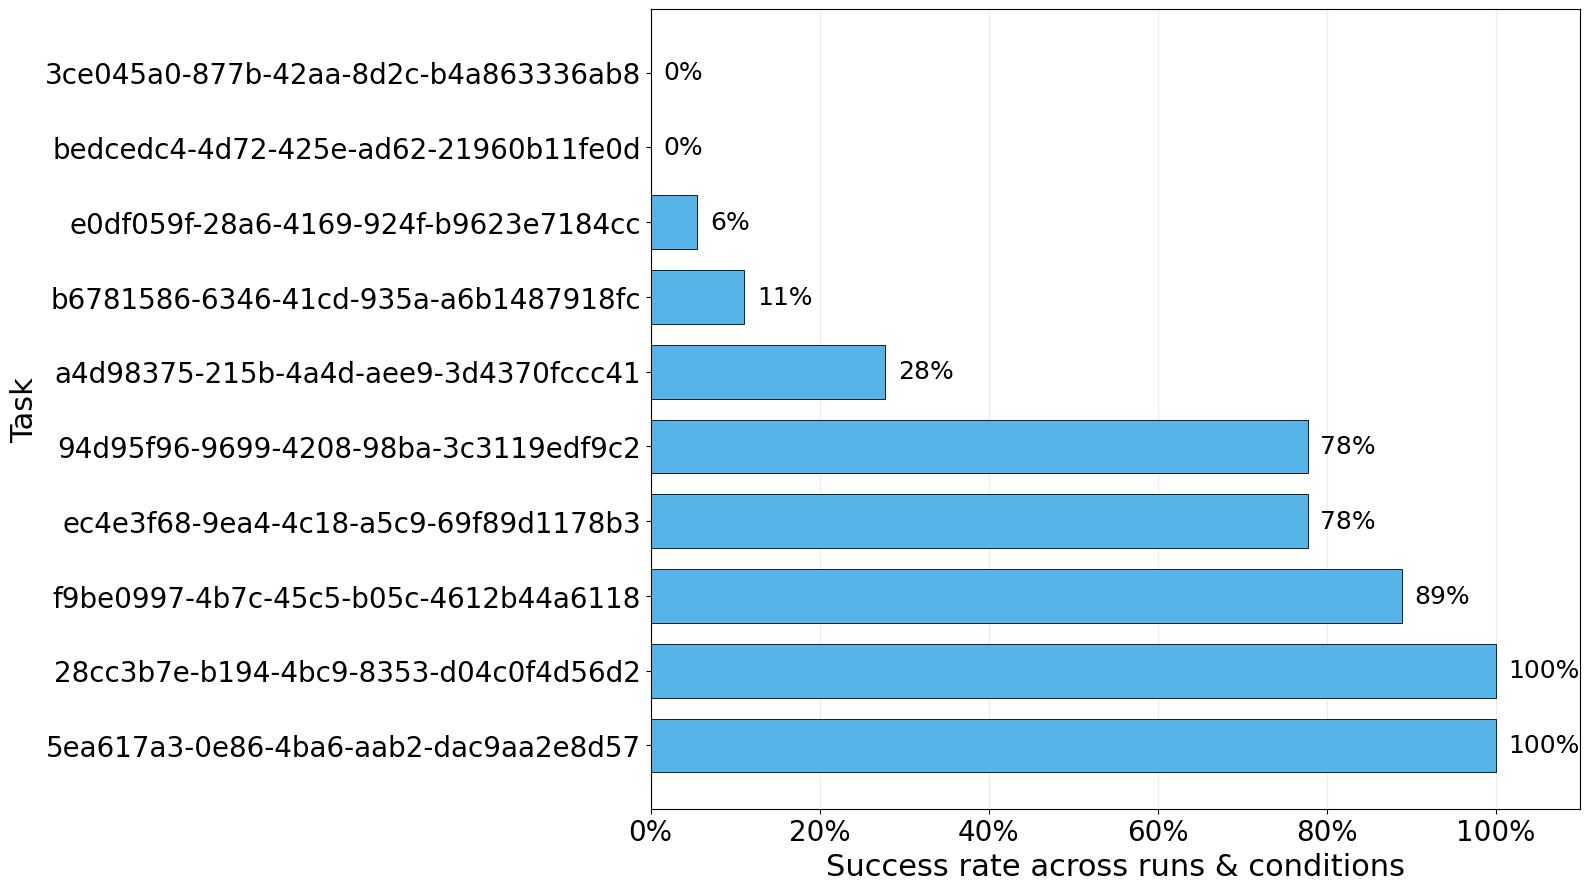

In [9]:
TASK_DIFFICULTY_PARAMS = {
    "task_col": TASK_COL,
    "fig_width": FIGURE_STYLE["single_plot_figsize"][0],
    "row_height": 0.72,
    "min_fig_height": FIGURE_STYLE["single_plot_figsize"][1],
    "tight_layout_rect": (0, 0, 1, 0.98),
    "task_label_max_chars": 36,
    "sort_by": ("success_rate", "duration_mean"),
    "sort_ascending": (True, False),
    "main_blue": "#56B4E9",
    "contrast_orange": "#D55E00",
    "bar_edgecolor": "black",
    "suptitle": None,
    "suptitle_fontsize": TEXT_STYLE["suptitle_fontsize"],
    "panel_title":None,
    "panel_title_fontsize": TEXT_STYLE["panel_title_fontsize"],
    "axis_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "xtick_fontsize": TEXT_STYLE["xtick_fontsize"],
    "ytick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "annotation_fontsize": ANNOTATION_STYLE["annotation_fontsize"],
    "bar_height": 0.72,
    "bar_linewidth": 0.6,
    "bar_alpha": 1.0,
    "grid_alpha": COMMON_PLOT_STYLE["grid_alpha"],
    "xlim": (0.0, 1.10),
    "show_reference_line": False,
    "reference_line_value": None,
    "reference_line_linestyle": "--",
    "reference_line_linewidth": 1.5,
    "reference_line_alpha": 0.9,
    "show_bar_values": True,
    "bar_value_fmt": "{:.0%}",
    "bar_value_dx": 0.015,
    "outpath_png": str(FIG_DIR / "task_difficulty_v3.png") if SAVE_FIGURES else None,
    "save_dpi": COMMON_PLOT_STYLE["save_dpi"],
}

fig_td, ax_td, task_profile = plot_task_difficulty_v3(
    df_all,
    **TASK_DIFFICULTY_PARAMS,
)
display(task_profile)
plt.show()


## Episode cost dashboard


,plot_condition,mean_llm_requests,std_llm_requests,mean_duration_sec,std_duration_sec,n_runs,total_episodes
0,Baseline | Vision ON,19.833333,1.001665,311.238833,47.973204,3,30
1,Baseline | Vision OFF,21.366667,2.731910,302.074233,72.620623,3,30
2,No STM | Vision ON,12.966667,1.021437,289.572033,37.212258,3,30
3,No STM | Vision OFF,14.666667,0.680686,266.358100,4.478452,3,30
4,Warm LTM | Vision ON,21.500000,2.253886,336.316433,56.661522,3,30
5,Warm LTM | Vision OFF,19.700000,1.646208,255.685867,46.837376,3,30


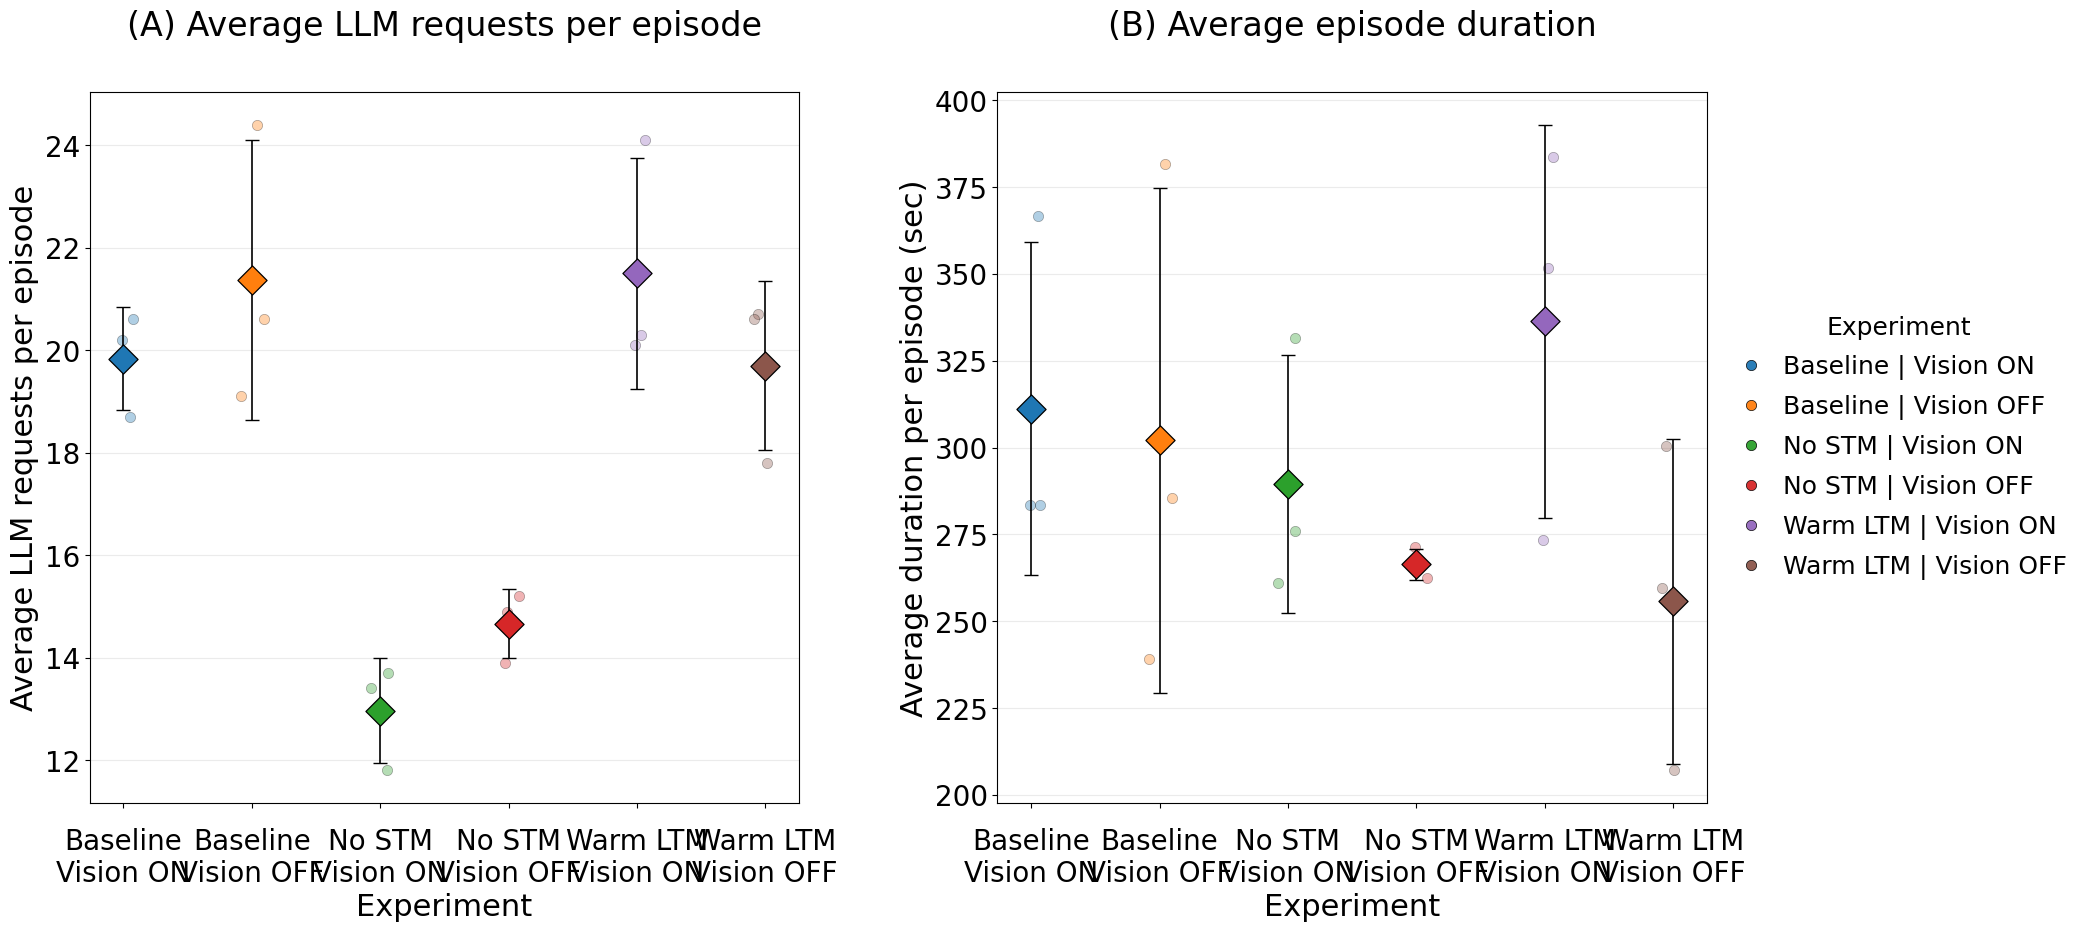

In [10]:
COST_PARAMS = {
    "cond_col": COND_COL,
    "outpath_png": str(FIG_DIR / "episode_cost_dashboard_v3.png") if SAVE_FIGURES else None,
    "title": None,
    "figsize": (21.0, 9.6),
    "wspace": 0.28,
    "hspace": 0.20,
    "point_size": 55,
    "point_alpha": 0.35,
    "point_edgecolor": "black",
    "point_linewidth": 0.5,
    "mean_marker": "D",
    "mean_marker_size": 220,
    "mean_alpha": 1.0,
    "mean_edgecolor": "black",
    "mean_linewidth": 0.9,
    "err_capsize": 5,
    "err_linewidth": 1.2,
    "jitter": 0.10,
    "random_seed": 42,
    "main_blue": "#56B4E9",
    "contrast_orange": "#D55E00",
    "blue_light": "#8ECAE6",
    "blue_dark": "#1F77B4",
    "fallback_cmap_name": "tab10",
    "suptitle_fontsize": TEXT_STYLE["suptitle_fontsize"],
    "panel_title_fontsize": TEXT_STYLE["panel_title_fontsize"],
    "axis_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "xtick_fontsize": TEXT_STYLE["xtick_fontsize"],
    "ytick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "legend_fontsize": TEXT_STYLE["legend_fontsize"],
    "legend_title_fontsize": TEXT_STYLE["legend_title_fontsize"],
    "suptitle_y": 0.98,
    "title_pad": 0,
    "title_y": 1.08,
    "show_legend": True,
    "legend_title": "Experiment",
    "legend_loc": "center left",
    "legend_bbox_to_anchor": (1.02, 0.5),
    "legend_frameon": False,
    "legend_ncol": 1,
    "legend_columnspacing": 1.2,
    "legend_handlelength": 1.6,
    "legend_handletextpad": 0.5,
    "legend_labelspacing": 0.6,
    "legend_borderaxespad": 0.0,
    "title_left": "(A) Average LLM requests per episode",
    "title_right": "(B) Average episode duration",
    "xlabel": "Experiment",
    "ylabel_left": "Average LLM requests per episode",
    "ylabel_right": "Average duration per episode (sec)",
    "xlabels_two_lines": COMMON_PLOT_STYLE["xlabels_two_lines"],
    "xtick_rotation": COMMON_PLOT_STYLE["xtick_rotation"],
    "xtick_pad": COMMON_PLOT_STYLE["xtick_pad"],
    "grid_alpha": COMMON_PLOT_STYLE["grid_alpha"],
    "save_dpi": COMMON_PLOT_STYLE["save_dpi"],
    "left_margin": 0.07,
    "right_margin": 0.84,
    "bottom_margin": 0.17,
    "top_margin": 0.91,
}

fig_cost, axes_cost, run_cost_tbl, cost_summary_tbl = plot_episode_cost_dashboard_v3(
    df_all,
    **COST_PARAMS,
)
display(cost_summary_tbl)
plt.show()


## Chunk dashboard


In [11]:
CHUNK_TABLES = build_chunk_dashboard_tables(
    df_all,
    cond_col=COND_COL,
    task_col=TASK_COL,
    rate_mode="weighted",
)
display(CHUNK_TABLES["rc"])
display(CHUNK_TABLES["cnt"])
display(CHUNK_TABLES["dyn_mean"])


,mean,std
plot_condition,,
Baseline | Vision ON,0.536523,0.015970
Baseline | Vision OFF,0.535138,0.077761
No STM | Vision ON,0.591856,0.045484
No STM | Vision OFF,0.500717,0.037653
Warm LTM | Vision ON,0.477111,0.088646
Warm LTM | Vision OFF,0.549708,0.093834


,chunks_success,chunks_fail
plot_condition,,
Baseline | Vision ON,3.433333,2.966667
Baseline | Vision OFF,3.666667,3.266667
No STM | Vision ON,3.633333,2.533333
No STM | Vision OFF,3.533333,3.533333
Warm LTM | Vision ON,3.300000,3.700000
Warm LTM | Vision OFF,3.466667,2.900000


,first_failure_chunk_index,max_consecutive_chunk_failures
plot_condition,,
Baseline | Vision ON,1.730159,2.400000
Baseline | Vision OFF,2.416667,2.566667
No STM | Vision ON,2.132275,2.300000
No STM | Vision OFF,2.301587,3.000000
Warm LTM | Vision ON,1.954365,3.166667
Warm LTM | Vision OFF,2.603175,2.566667


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

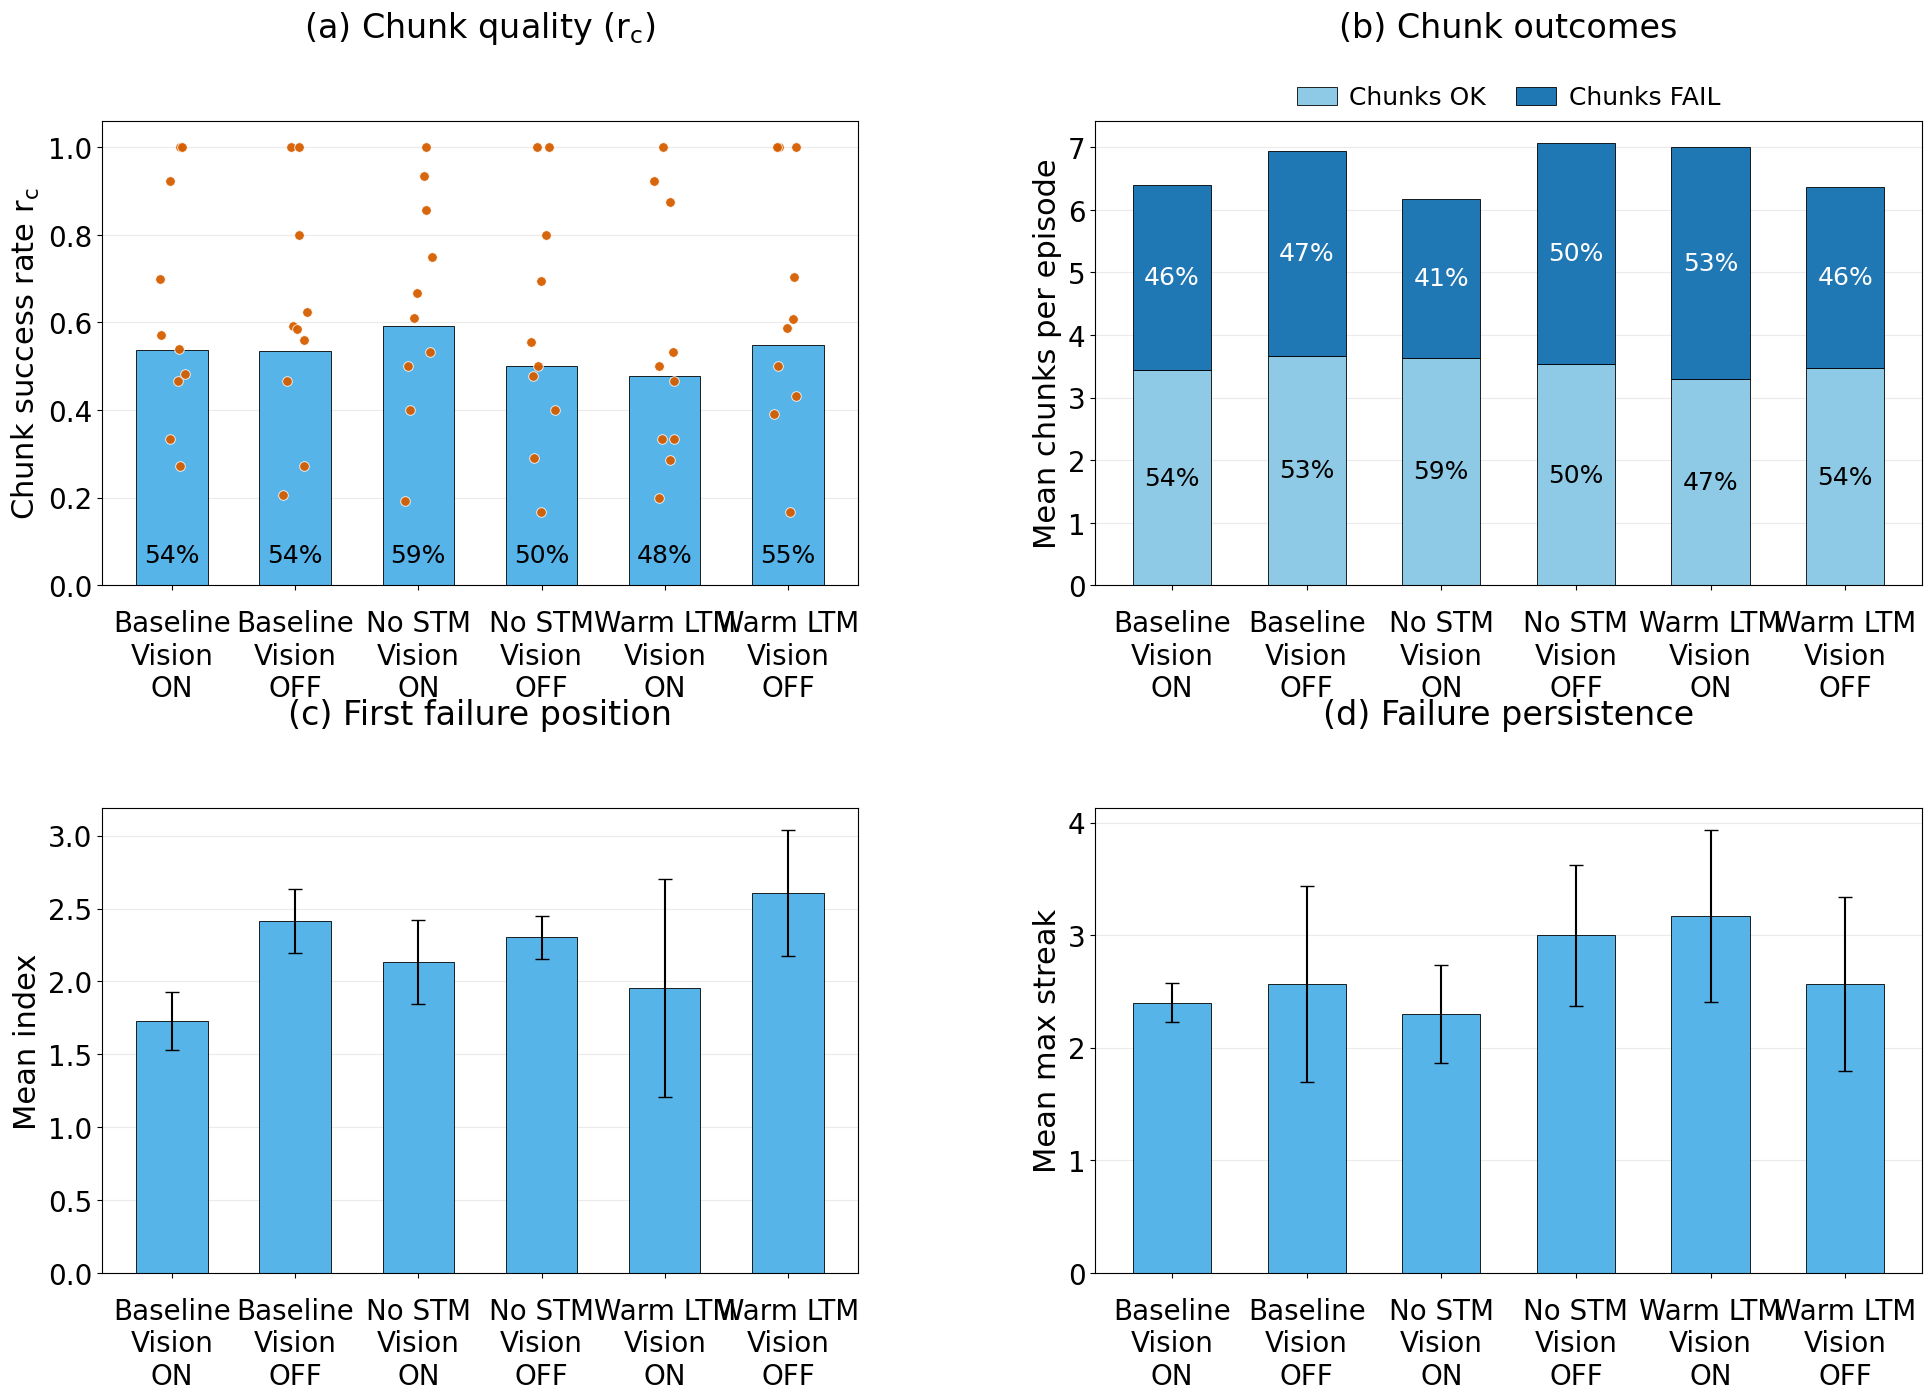

In [12]:
CHUNK_PARAMS = {
    "outpath_png": str(FIG_DIR / "chunk_dashboard_v3.png") if SAVE_FIGURES else None,
    "title": None,
    "figsize": (20.0, 14.4),
    "width_ratios": (1.08, 1.18),
    "height_ratios": (1.08, 1.08),
    "hspace": 0.48,
    "wspace": 0.30,
    "bar_width": 0.58,
    "bar_edgecolor": "black",
    "bar_linewidth": 0.6,
    "err_capsize": 5,
    "scatter_size": 48,
    "scatter_alpha": 0.95,
    "scatter_edgecolor": "white",
    "scatter_linewidth": 0.6,
    "jitter_frac": 0.40,
    "main_blue": "#56B4E9",
    "contrast_orange": "#D55E00",
    "blue_light": "#8ECAE6",
    "blue_dark": "#1F77B4",
    "suptitle_fontsize": TEXT_STYLE["suptitle_fontsize"],
    "panel_title_fontsize": TEXT_STYLE["panel_title_fontsize"],
    "axis_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "xtick_fontsize": TEXT_STYLE["xtick_fontsize"],
    "ytick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "legend_fontsize": TEXT_STYLE["legend_fontsize"],
    "suptitle_y": 0.98,
    "title_pad": 0,
    "title_y": 1.18,
    "legend_outside": True,
    "legend_y": 1.05,
    "legend_ncol": 2,
    "legend_columnspacing": 1.2,
    "legend_handlelength": 1.6,
    "legend_handletextpad": 0.5,
    "legend_labelspacing": 0.6,
    "xlabels_two_lines": COMMON_PLOT_STYLE["xlabels_two_lines"],
    "compact_condition_labels": True,
    "xtick_rotation": COMMON_PLOT_STYLE["xtick_rotation"],
    "xtick_pad": COMMON_PLOT_STYLE["xtick_pad"],
    "grid_alpha": COMMON_PLOT_STYLE["grid_alpha"],
    "ypad_top": 0.06,
    "ylim_a_max": 1.15,
    "save_dpi": COMMON_PLOT_STYLE["save_dpi"],
    "cond_col": COND_COL,
    "task_col": TASK_COL,
    "chunk_rate_mode": "weighted",
    "binary_label_fontsize": ANNOTATION_STYLE["binary_label_fontsize"],
    "rate_label_fontsize": ANNOTATION_STYLE["rate_label_fontsize"],
    "show_quality_error_bars": False,
    "show_quality_bar_labels": True,
    "quality_bar_label_position": "base",
    "quality_bar_label_base_frac": 0.04,
    "left_margin": 0.07,
    "right_margin": 0.98,
    "bottom_margin": 0.13,
    "top_margin": 0.93,
}

fig_chunk, axes_chunk, chunk_tables = plot_chunk_dashboard_v3(
    df_all,
    **CHUNK_PARAMS,
)
plt.show()


## Step dashboard


In [13]:
steps_summary_tbl = build_steps_summary_table(
    df_all,
    cond_col=COND_COL,
)
display(steps_summary_tbl)


,Condition,Step success rate $r_s$,Steps evaluated,Steps OK,Steps FAIL,WAIT share,PYTHON share,Avg pause/step (s),LLM calls
0,Baseline | Vision ON,70.0%,9.7,5.9,3.8,10.9%,89.1%,3.43,19.8
1,Baseline | Vision OFF,71.2%,10.6,6.5,4.1,9.1%,90.9%,3.37,21.4
2,No STM | Vision ON,72.3%,9.6,6.2,3.4,11.6%,88.4%,3.54,13.0
3,No STM | Vision OFF,69.1%,10.7,6.3,4.4,9.8%,90.2%,3.41,14.7
4,Warm LTM | Vision ON,67.4%,10.7,5.9,4.8,11.3%,88.7%,3.55,21.5
5,Warm LTM | Vision OFF,73.2%,9.6,5.6,4.0,7.5%,92.5%,3.51,19.7


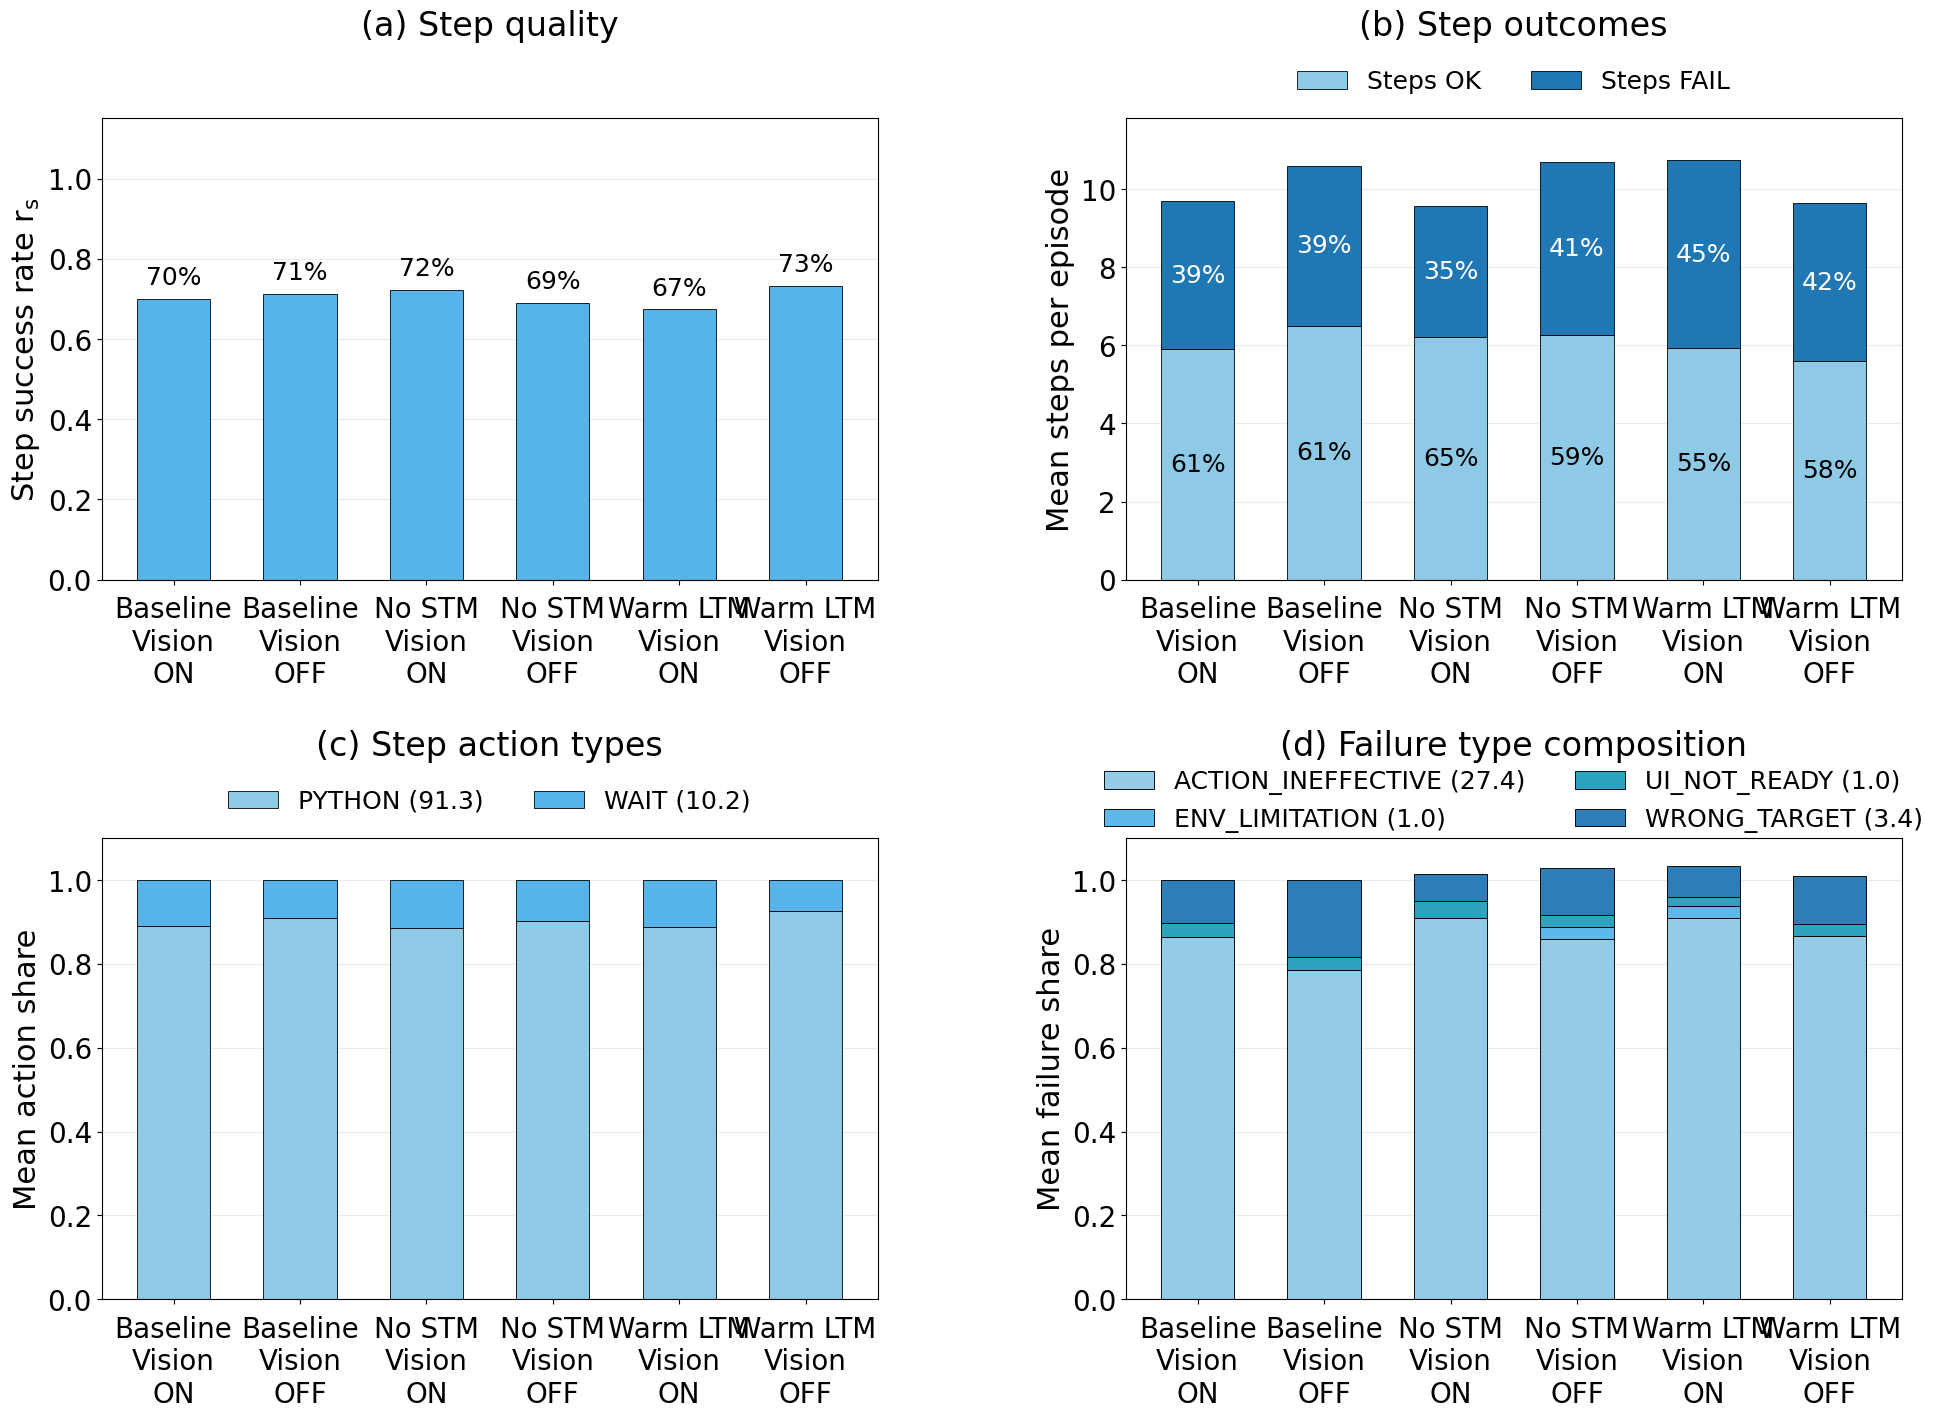

In [14]:
STEPS_PARAMS = {
    "cond_col": COND_COL,
    "outpath_png": str(FIG_DIR / "steps_dashboard_v8.png") if SAVE_FIGURES else None,
    "save_dpi": COMMON_PLOT_STYLE["save_dpi"],
    "figsize": (20.0, 14.4),
    "bar_width": 0.58,
    "hspace": 0.56,
    "wspace": 0.32,
    "axis_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "xtick_fontsize": TEXT_STYLE["xtick_fontsize"],
    "ytick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "panel_title_fontsize": TEXT_STYLE["panel_title_fontsize"],
    "title_pad": 0,
    "title_y": 1.18,
    "xlabels_two_lines": COMMON_PLOT_STYLE["xlabels_two_lines"],
    "compact_condition_labels": True,
    "y_headroom_frac": 0.10,
    "ylabel_C": "Mean action share",
    "ylabel_D": "Mean failure share",
    "legend_outside": True,
    "legend_fontsize": TEXT_STYLE["legend_fontsize"],
    "legend_ncol": 2,
    "legend_y": 1.08,
    "emphasize_D_edge": True,
    "binary_label_fontsize": ANNOTATION_STYLE["binary_label_fontsize"],
    "rate_label_fontsize": ANNOTATION_STYLE["rate_label_fontsize"],
    "action_share_label_fontsize": ANNOTATION_STYLE["action_share_label_fontsize"],
    "show_quality_error_bars": False,
    "annotate_action_shares": False,
    "left_margin": 0.06,
    "right_margin": 0.96,
    "bottom_margin": 0.14,
    "top_margin": 0.96,
}

fig_steps, axes_steps, failure_tbl = plot_steps_dashboard_v8(
    df_all,
    **STEPS_PARAMS,
)
plt.show()


## Recovery dashboard


,plot_condition,recoveries_after_fail_total_mean,recoveries_after_fail_total_std,recoveries_after_fail_opportunities_mean,recoveries_after_fail_opportunities_std,recovery_after_fail_rate_mean,recovery_after_fail_rate_std
0,Baseline | Vision ON,0.833333,0.057735,2.666667,0.057735,0.485606,0.032836
1,Baseline | Vision OFF,0.866667,0.251661,2.900000,0.854400,0.388558,0.060127
2,No STM | Vision ON,0.666667,0.057735,2.233333,0.404145,0.547619,0.083333
3,No STM | Vision OFF,0.700000,0.400000,3.133333,0.305505,0.331576,0.194080
4,Warm LTM | Vision ON,0.700000,0.264575,3.233333,0.971253,0.324504,0.126759
5,Warm LTM | Vision OFF,0.600000,0.100000,2.633333,0.737111,0.388265,0.016790


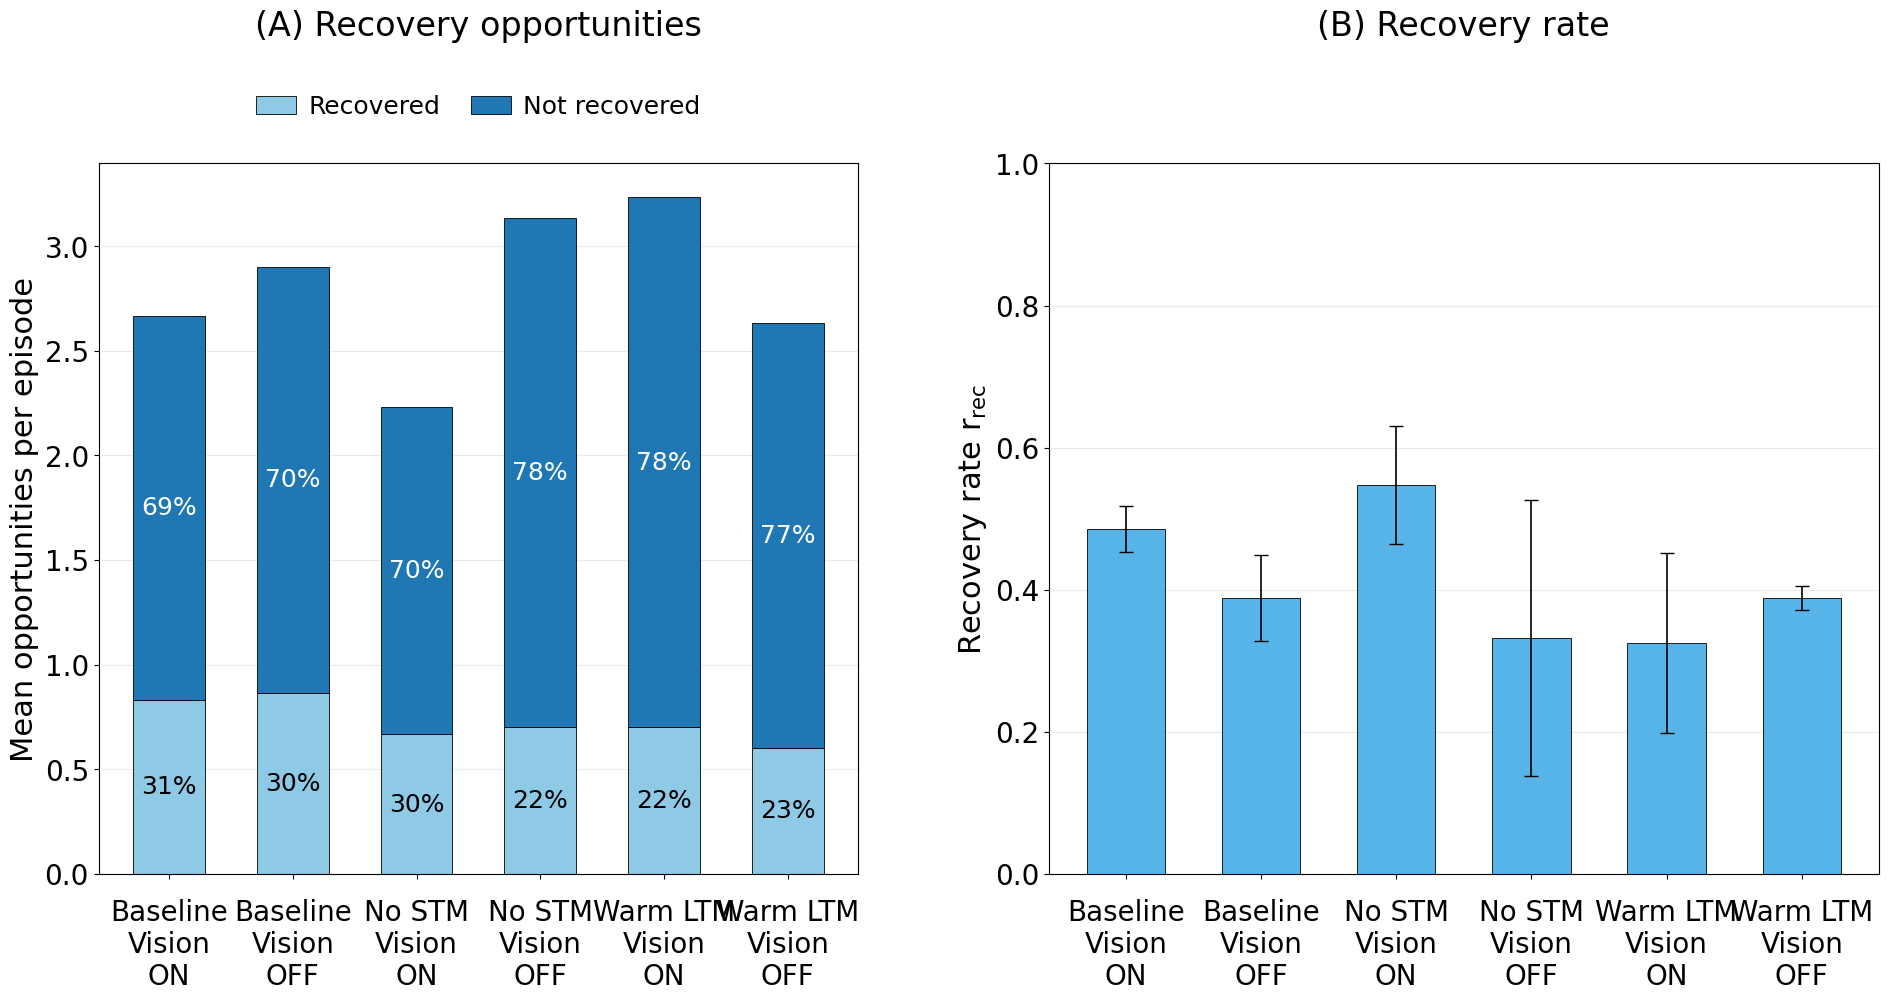

In [15]:
ERROR_PARAMS = {
    "cond_col": COND_COL,
    "run_col": "run_id",
    "outpath_png": str(FIG_DIR / "error_dashboard_v3.png") if SAVE_FIGURES else None,
    "title": None,
    "figsize": (20.0, 9.6),
    "width_ratios": (1.08, 1.18),
    "wspace": 0.24,
    "bar_width": 0.58,
    "bar_edgecolor": "black",
    "bar_linewidth": 0.6,
    "err_capsize": 5,
    "err_linewidth": 1.2,
    "main_blue": "#56B4E9",
    "blue_light": "#8ECAE6",
    "blue_dark": "#1F77B4",
    "suptitle_fontsize": TEXT_STYLE["suptitle_fontsize"],
    "panel_title_fontsize": TEXT_STYLE["panel_title_fontsize"],
    "axis_label_fontsize": TEXT_STYLE["axis_label_fontsize"],
    "xtick_fontsize": TEXT_STYLE["xtick_fontsize"],
    "ytick_fontsize": TEXT_STYLE["ytick_fontsize"],
    "legend_fontsize": TEXT_STYLE["legend_fontsize"],
    "suptitle_y": 0.98,
    "title_pad": 0,
    "title_y": 1.18,
    "legend_outside": True,
    "legend_y": 1.08,
    "legend_loc": "center",
    "legend_ncol": 2,
    "legend_columnspacing": 1.2,
    "legend_handlelength": 1.6,
    "legend_handletextpad": 0.5,
    "legend_labelspacing": 0.6,
    "title_A": "(A) Recovery opportunities",
    "title_B": "(B) Recovery rate",
    "ylabel_A": "Mean opportunities per episode",
    "ylabel_B": "Recovery rate $r_{rec}$",
    "xlabels_two_lines": COMMON_PLOT_STYLE["xlabels_two_lines"],
    "compact_condition_labels": True,
    "xtick_rotation": COMMON_PLOT_STYLE["xtick_rotation"],
    "xtick_pad": COMMON_PLOT_STYLE["xtick_pad"],
    "grid_alpha": COMMON_PLOT_STYLE["grid_alpha"],
    "ylim_rate": (0.0, 1.0),
    "save_dpi": COMMON_PLOT_STYLE["save_dpi"],
    "binary_label_fontsize": ANNOTATION_STYLE["binary_label_fontsize"],
    "left_margin": 0.07,
    "right_margin": 0.96,
    "bottom_margin": 0.17,
    "top_margin": 0.91,
}

fig_err, axes_err, recovery_tbl = plot_error_dashboard_v3(
    df_all,
    **ERROR_PARAMS,
)
display(recovery_tbl)
plt.show()
